In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
from pathlib import Path
sys.path.append('../scripts') # Point to scripts folder

# Connect notebook to the 'src' folder
current_dir = Path(os.getcwd())
src_dir = current_dir.parent / "src"
sys.path.append(str(src_dir))

import data, signals, backtest

Project Root: /Users/marekkiedrowicz/Documents/GitHub/macro-portfolio-lab
Data Directory: /Users/marekkiedrowicz/Documents/GitHub/macro-portfolio-lab/data


In [3]:
# Load clean prices using custom module
prices = data.load_prices("market_prices.csv")
prices = data.clean_prices(prices)

In [4]:
# Generate signals and weights
ts_signals = signals.calc_ts_momentum(prices, lookback=252, skip=21)
rolling_vol = signals.calc_rolling_volatility(prices, window=60)
target_weights = signals.calc_inverse_vol_weights(rolling_vol, ts_signals)

In [5]:
# Run the backtest engine
results = backtest.run_backtest_ts_momentum(prices, ts_signals, target_weights)

--- Vol-Targeted Momentum ---
CAGR: 5.95%
Annual Volatility: 8.78%
Sharpe Ratio: 0.45
Max Drawdown: -23.57%

--- SPY Benchmark ---
CAGR: 14.31%
Annual Volatility: 16.97%
Sharpe Ratio: 0.73
Max Drawdown: -24.50%



<Axes: title={'center': 'Asset Weights & Rebalancing Over Time'}, xlabel='Date'>

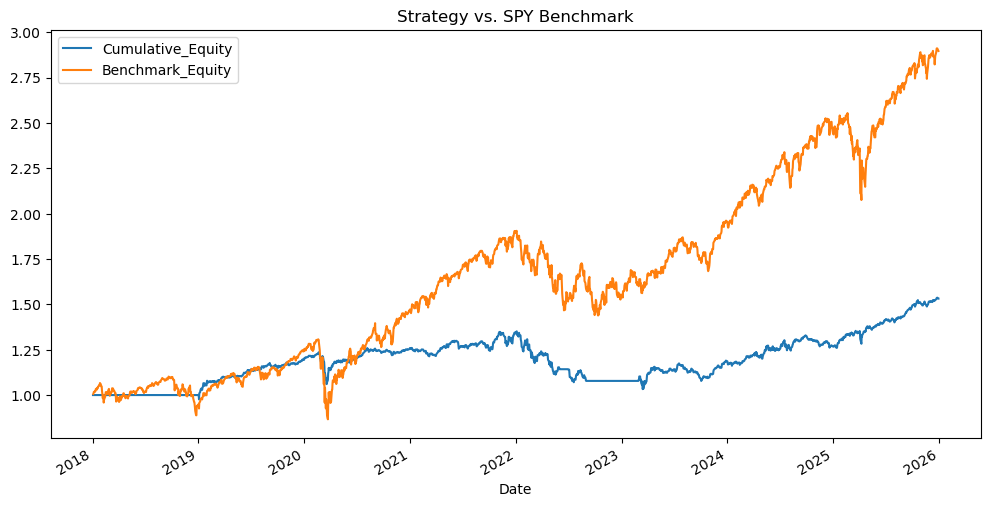

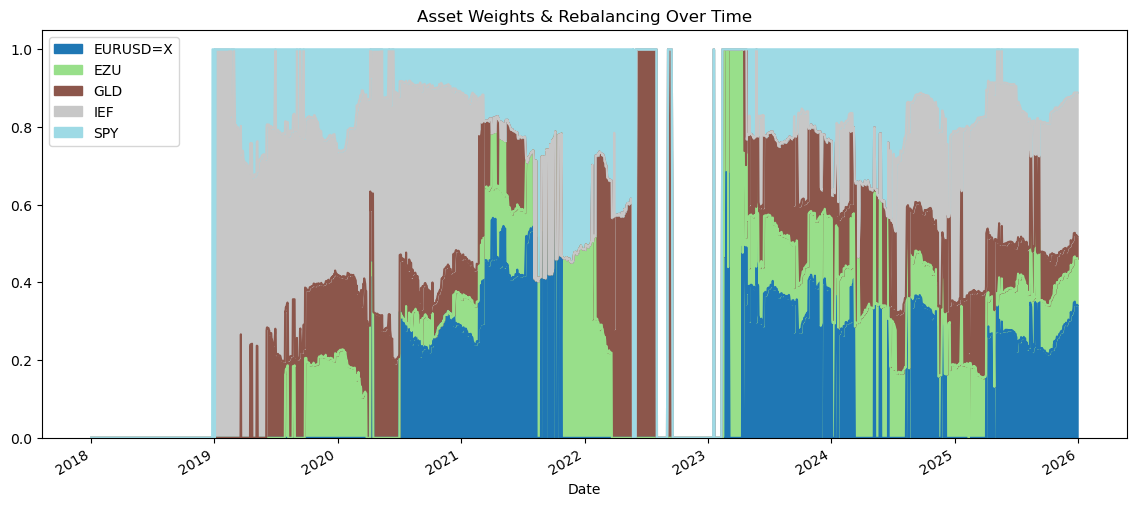

In [6]:
# 1. Add Benchmark (SPY Buy & Hold)
# Assuming 'prices' is original dataframe and 'results' contains your strategy
benchmark_returns = np.log(prices['SPY'] / prices['SPY'].shift(1))
results['Benchmark_Equity'] = np.exp(benchmark_returns.cumsum())

# Plot Strategy vs Benchmark
results[['Cumulative_Equity', 'Benchmark_Equity']].plot(figsize=(12, 6), title="Strategy vs. SPY Benchmark")

# 2. Calculate & Print Portfolio Metrics
def print_metrics(equity_curve, name, rf_rate=0.02):
    """Calculates approximate annualized metrics."""
    # Filter out the initial 252-day flatline period for accurate metrics
    active_curve = equity_curve[equity_curve > 1.0001] 
    
    if active_curve.empty:
        return
        
    daily_ret = active_curve.pct_change().dropna()
    cagr = (active_curve.iloc[-1] / active_curve.iloc[0]) ** (252 / len(active_curve)) - 1
    vol = daily_ret.std() * np.sqrt(252)
    sharpe = (cagr - rf_rate) / vol if vol > 0 else 0
    max_dd = ((active_curve / active_curve.cummax()) - 1).min()
    
    print(f"--- {name} ---")
    print(f"CAGR: {cagr:.2%}")
    print(f"Annual Volatility: {vol:.2%}")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Max Drawdown: {max_dd:.2%}\n")

print_metrics(results['Cumulative_Equity'], "Vol-Targeted Momentum")
print_metrics(results['Benchmark_Equity'], "SPY Benchmark")

# 3. Visualize Rebalancing & Turnover
# Plotting the target_weights dataframe as an area chart shows asset allocation drift
target_weights.plot.area(figsize=(14, 6), title="Asset Weights & Rebalancing Over Time", colormap='tab20')

In [8]:
# 1. Generate Long/Short Signals and Weights
ls_signals = signals.calc_ls_ts_momentum(prices, lookback=252, skip=21)
ls_weights = signals.calc_ls_inv_vol_weights(rolling_vol, ls_signals)

# 2. Run Long/Short Backtest (using your updated TC-aware function)
ls_results = backtest.run_backtest_ts_momentum(prices, ls_signals, ls_weights, tc_bps=10.0)

# 3. Store L/S results in your main dataframe for comparison
results['LS_Cumulative_Equity'] = ls_results['Cumulative_Equity']

--- Long-Only Momentum ---
CAGR: 5.95%
Annual Volatility: 8.78%
Sharpe Ratio: 0.45
Max Drawdown: -23.57%

--- Long/Short Momentum ---
CAGR: 2.20%
Annual Volatility: 5.75%
Sharpe Ratio: 0.03
Max Drawdown: -12.51%

--- SPY Benchmark ---
CAGR: 14.31%
Annual Volatility: 16.97%
Sharpe Ratio: 0.73
Max Drawdown: -24.50%



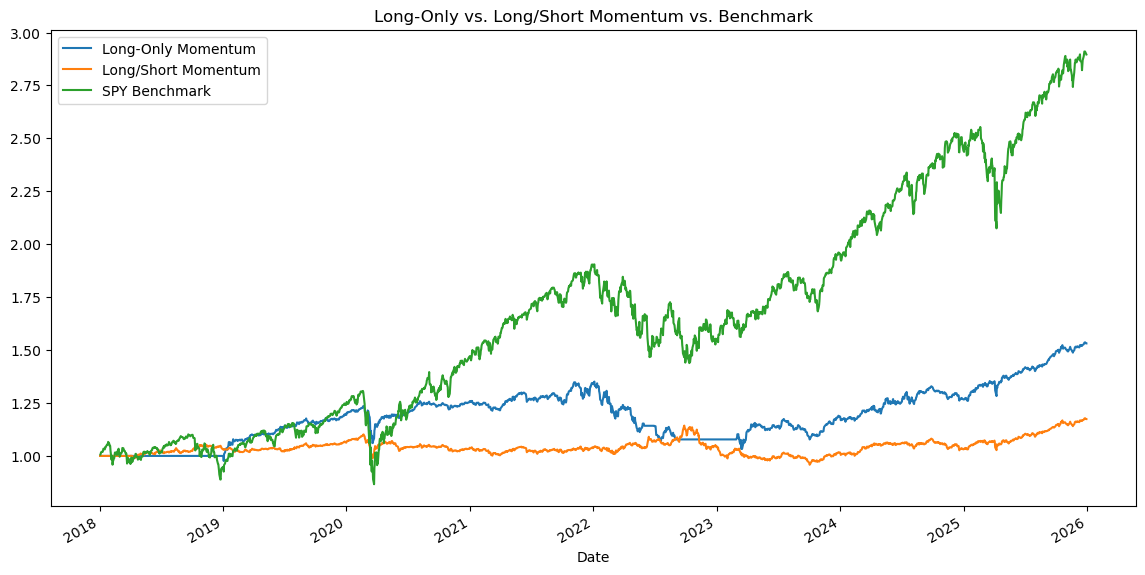

In [9]:
# 4. Plot Long-Only vs. Long/Short vs. Benchmark
results[['Cumulative_Equity', 'LS_Cumulative_Equity', 'Benchmark_Equity']].rename(
    columns={
        'Cumulative_Equity': 'Long-Only Momentum',
        'LS_Cumulative_Equity': 'Long/Short Momentum', 
        'Benchmark_Equity': 'SPY Benchmark'
    }
).plot(figsize=(14, 7), title="Long-Only vs. Long/Short Momentum vs. Benchmark")

# 5. Print Metrics for Comparison
print_metrics(results['Cumulative_Equity'], "Long-Only Momentum")
print_metrics(results['LS_Cumulative_Equity'], "Long/Short Momentum")
print_metrics(results['Benchmark_Equity'], "SPY Benchmark")